# 3.1 Úvod do scikit-learn

## Lineární regrese

### Generování dat

In [1]:
import numpy as np
np.random.seed(0)

# Scikit-learn
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# funkce pocitajici data a vnasejici do nich sum (noise) 
def funkce(x, noise):
    return .6 *  x + (x ** .8) * noise

In [3]:
# generovani trenovacich dat 
pocet = 20
mnozstvi_sumu = 0.9
# prvky
X_train = np.sort(np.random.rand(pocet))
# zanesme sum
sum_train = np.random.rand(pocet) * mnozstvi_sumu

# cile (reference, labely, targets)
y_train = funkce(X_train, sum_train) 
X_train = X_train.reshape(-1, 1)  # sloupcovy vektor

# vytvorme testovaci data z tez funkce 
pocet_test = 20
# testovaci prvky
X_test = np.sort(np.random.rand(pocet_test))

# cile (reference, labely, targets)
sum_test = np.random.rand(pocet_test) * mnozstvi_sumu
y_test = funkce(X_test, sum_test)
X_test = X_test.reshape(-1, 1)

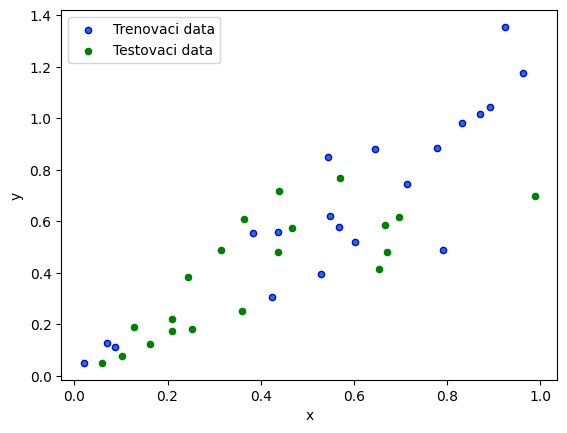

In [4]:
# podivejme se na data skrze rozptylovy diagram
plt.scatter(X_train, y_train, edgecolor="b", s=20, label="Trenovaci data")
plt.scatter(X_test, y_test, edgecolor="g", color="g", s=20, label="Testovaci data")
plt.xlabel("x")
plt.ylabel("y")
plt.legend(loc="best")

### Lineární regrese v scikit-learn

In [5]:
# vytvorme model
linear_regression = LinearRegression()
# trenujme jej na trenovacich datech 
linear_regression.fit(X_train, y_train)

LinearRegression()

In [6]:
linear_regression.fit_intercept

True

In [7]:
linear_regression.coef_

array([1.14988114])

In [8]:
linear_regression.intercept_

np.float64(-0.006760181988206382)

In [9]:
y_train_pred = linear_regression.predict(X_train)
MSE_train = mean_squared_error(y_train, y_train_pred)
print(f'MSE training: {round(MSE_train, 3)}')

MSE training: 0.024


In [10]:
y_test_pred = linear_regression.predict(X_test)
MSE_test = mean_squared_error(y_test, y_test_pred)
print(f'MSE training: {round(MSE_test, 3)}')

MSE training: 0.031


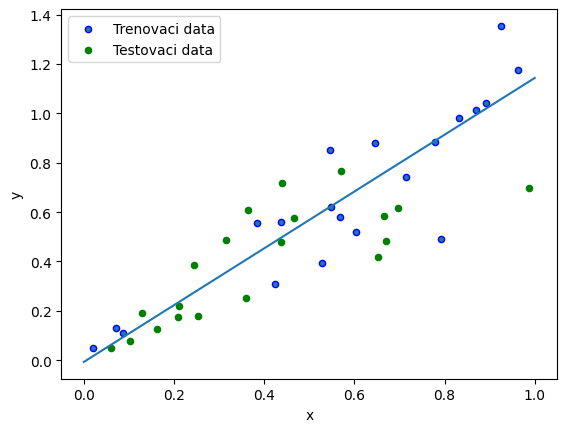

In [11]:
# podivejme se na data skrze rozptylovy diagram
plt.scatter(X_train, y_train, edgecolor="b", s=20, label="Trenovaci data")
plt.scatter(X_test, y_test, edgecolor="g", color="g", s=20, label="Testovaci data")
plt.xlabel("x")
plt.ylabel("y")
plt.legend(loc="best")

X_plot = np.linspace(0, 1, 100)
y_plot = linear_regression.predict(X_plot.reshape(-1, 1))
plt.plot(X_plot, y_plot)

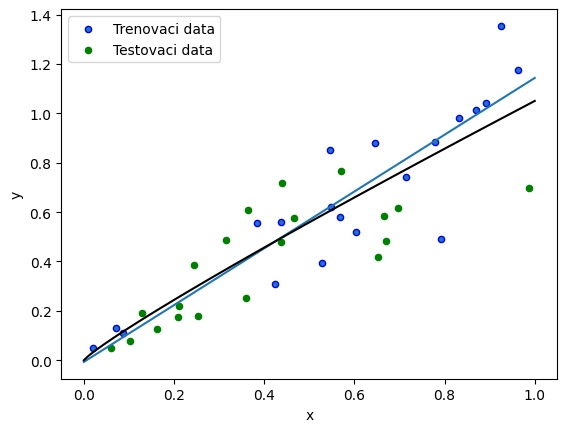

In [12]:
X_funkce = np.linspace(0, 1, 100)
sum_hodnoty = np.ones(100) / 2. * mnozstvi_sumu
y_fun = funkce(X_funkce, sum_hodnoty)

# podivejme se na data skrze rozptylovy diagram
plt.scatter(X_train, y_train, edgecolor="b", s=20, label="Trenovaci data")
plt.scatter(X_test, y_test, edgecolor="g", color="g", s=20, label="Testovaci data")
plt.xlabel("x")
plt.ylabel("y")
plt.legend(loc="best")

X_plot = np.linspace(0, 1, 100)
y_plot = linear_regression.predict(X_plot.reshape(-1, 1))
plt.plot(X_plot, y_plot)

plt.plot(X_funkce, y_fun, color="k",  label="Underlying function")

## Polynomická regrese

### Generování dat

In [13]:
# funkce pocitajici data a vnasejici do nich sum (noise) 
def funkce(x, noise):
    return .6 *  np.sin(x) + x + (x ** .8) * noise

In [14]:
# generovani trenovacich dat 
pocet = 20
mnozstvi_sumu = 0.7
# prvky
X_train = np.sort(np.random.rand(pocet))
# zanesme sum
sum_train = np.random.rand(pocet) * mnozstvi_sumu

# cile (reference, labely, targets)
y_train = funkce(X_train, sum_train) 
X_train = X_train.reshape(-1, 1)  # sloupcovy vektor

# vytvorme testovaci data z tez funkce 
pocet_test = 20
# testovaci prvky
X_test = np.sort(np.random.rand(pocet_test))

# cile (reference, labely, targets)
sum_test = np.random.rand(pocet_test) * mnozstvi_sumu
y_test = funkce(X_test, sum_test)
X_test = X_test.reshape(-1, 1)

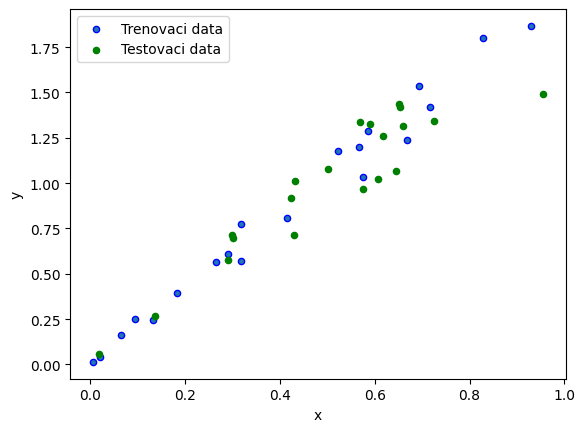

In [15]:
# podivejme se na data skrze rozptylovy diagram
plt.scatter(X_train, y_train, edgecolor="b", s=20, label="Trenovaci data")
plt.scatter(X_test, y_test, edgecolor="g", color="g", s=20, label="Testovaci data")
plt.xlabel("x")
plt.ylabel("y")
plt.legend(loc="best")

In [16]:
# Transformujme vstupni data na polynomialni
stupne = 10
# definujme prvky
poly = PolynomialFeatures(degree=stupne, include_bias=False)
# transformujme trenovaci data
polynomial_features = poly.fit_transform(X_train.reshape(-1, 1))

In [17]:
# vytvorme model
linear_regression = LinearRegression()
# trenujme model na trenovacich datech
linear_regression.fit(polynomial_features, y_train)

LinearRegression()

In [18]:
# spustme predikci
y_train_pred = linear_regression.predict(polynomial_features)
MSE_train = mean_squared_error(y_train, y_train_pred)
print(f'MSE training: {round(MSE_train, 3)}')

MSE training: 0.005


In [19]:
# zhodnotme model na testovacich datech
test_features = poly.fit_transform(X_test.reshape(-1, 1))
y_pred = linear_regression.predict(test_features)
MSE_test = mean_squared_error(y_test, y_pred)
print(f'MSE testing: {round(MSE_test, 3)}')


MSE testing: 0.384


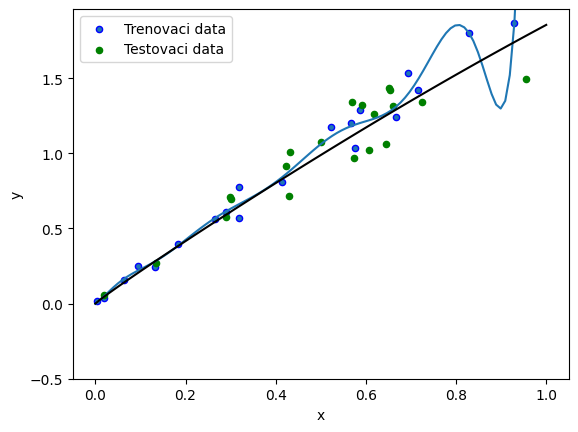

In [20]:
X_funkce = np.linspace(0, 1, 100)
sum_hodnoty = np.ones(100) / 2. * mnozstvi_sumu
y_fun = funkce(X_funkce, sum_hodnoty)

# podivejme se na data skrze rozptylovy diagram
plt.scatter(X_train, y_train, edgecolor="b", s=20, label="Trenovaci data")
plt.scatter(X_test, y_test, edgecolor="g", color="g", s=20, label="Testovaci data")
plt.xlabel("x")
plt.ylabel("y")
plt.legend(loc="best")
plt.ylim(-0.5)

X_plot = np.linspace(0, 1, 100)
plot_polynomial_features = poly.fit_transform(X_plot.reshape(-1, 1))
y_plot = linear_regression.predict(plot_polynomial_features)
plt.plot(X_plot, y_plot)

plt.plot(X_funkce, y_fun, color="k",  label="Underlying function")